Angela Chen  
This is the medical records of 299 patients who experienced heart failure (dataset from 2020).  
Research Question: How are certain clinical characteristics associated with death among patients with heart failure?
Source:https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('/heart+failure+clinical+records.zip')

In [ ]:
#Inspect Data
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
df.tail()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0
298,50.0,0,196,0,45,0,395000.0,1.6,136,1,1,285,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 299
Columns: 13


In [ ]:
df.index

RangeIndex(start=0, stop=299, step=1)

In [ ]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [ ]:
df.dtypes

,0
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


In [ ]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
df.count()

,0
age,299
anaemia,299
creatinine_phosphokinase,299
diabetes,299
ejection_fraction,299
high_blood_pressure,299
platelets,299
serum_creatinine,299
serum_sodium,299
sex,299


In [ ]:
#Cleaning the data
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
df.rename(columns={'anaemia':'anemia', 'creatinine_phosphokinase':'CPK(mcg/L)', 'sex':'gender', 'time':'follow_up(days)'}, inplace=True)

In [ ]:
df.head()

,age,anemia,CPK(mcg/L),diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,gender,smoking,follow_up(days),DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
#Convert binary values (to make easier to read)
df['anemia'] = df['anemia'].replace({1:'Yes', 0:'No'})
df['diabetes'] = df['diabetes'].replace({1:'Yes', 0:'No'})
df['high_blood_pressure'] = df['high_blood_pressure'].replace({1:'Yes', 0:'No'})
df['gender'] = df['gender'].replace({1:'Male', 0:'Female'})
df['smoking'] = df['smoking'].replace({1:'Yes', 0:'No'})
df['DEATH_EVENT'] = df['DEATH_EVENT'].replace({1:'Death event', 0:'Survived'})

In [ ]:
df.head()

,age,anemia,CPK(mcg/L),diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,gender,smoking,follow_up(days),DEATH_EVENT
0,75.0,No,582,No,20,Yes,265000.00,1.9,130,Male,No,4,Death event
1,55.0,No,7861,No,38,No,263358.03,1.1,136,Male,No,6,Death event
2,65.0,No,146,No,20,No,162000.00,1.3,129,Male,Yes,7,Death event
3,50.0,Yes,111,No,20,No,210000.00,1.9,137,Male,No,7,Death event
4,65.0,Yes,160,Yes,20,No,327000.00,2.7,116,Female,No,8,Death event


In [ ]:
#Creating Age Groups (binning using pandas function)
df['age_group'] = pd.cut(df['age'], bins=[0, 49, 59, 69, 100], labels=['Under 50', '50-59', '60-69', '70+'])

In [ ]:
df.head(15)

,age,anemia,CPK(mcg/L),diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,gender,smoking,follow_up(days),DEATH_EVENT,age_group
0,75.0,No,582,No,20,Yes,265000.00,1.9,130,Male,No,4,Death event,70+
1,55.0,No,7861,No,38,No,263358.03,1.1,136,Male,No,6,Death event,50-59
2,65.0,No,146,No,20,No,162000.00,1.3,129,Male,Yes,7,Death event,60-69
3,50.0,Yes,111,No,20,No,210000.00,1.9,137,Male,No,7,Death event,50-59
4,65.0,Yes,160,Yes,20,No,327000.00,2.7,116,Female,No,8,Death event,60-69
5,90.0,Yes,47,No,40,Yes,204000.00,2.1,132,Male,Yes,8,Death event,70+
6,75.0,Yes,246,No,15,No,127000.00,1.2,137,Male,No,10,Death event,70+
7,60.0,Yes,315,Yes,60,No,454000.00,1.1,131,Male,Yes,10,Death event,60-69
8,65.0,No,157,No,65,No,263358.03,1.5,138,Female,No,10,Death event,60-69
9,80.0,Yes,123,No,35,Yes,388000.00,9.4,133,Male,Yes,10,Death event,70+


In [ ]:
#Descriptive Statistics
df.groupby('DEATH_EVENT')[['age', 'ejection_fraction', 'serum_creatinine']].agg(['mean', 'median', 'std'])

age                   ejection_fraction                    \
                  mean median        std              mean median        std   
DEATH_EVENT                                                                    
Death event  65.215281   65.0  13.214556          33.46875   30.0  12.525303   
Survived     58.761906   60.0  10.637890          40.26601   38.0  10.859963   

            serum_creatinine                   
                        mean median       std  
DEATH_EVENT                                    
Death event         1.835833    1.3  1.468562  
Survived            1.184877    1.0  0.654083

The above compares the outcome of heart failure based on age, ejection fraction, and serum creatinine. This shows that some clinical characteristics may contribute to the outcome.

In [ ]:
df['age'].describe()

,age
count,299.000000
mean,60.833893
std,11.894809
min,40.000000
25%,51.000000
50%,60.000000
75%,70.000000
max,95.000000


The above shows average age where one is diagnosed, the youngest age diagnosed, the oldest diagnosed, etc.

In [ ]:
#Statistical Analysis (Inferential Statistics) using Welch's two-sample t-test
from scipy import stats

In [ ]:
survived_df = df[df['DEATH_EVENT'] == 'Survived']['ejection_fraction']
death_df = df[df['DEATH_EVENT'] == 'Death event']['ejection_fraction']

t_stat, p_value = stats.ttest_ind(survived_df, death_df, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.56698316342773
P-value: 9.647152798521775e-06


In [ ]:
print('Average ejection fraction - Survived:', survived_df.mean())
print('Average ejection fraction - Death:', death_df.mean())

Average ejection fraction - Survived: 40.26600985221675
Average ejection fraction - Death: 33.46875


Survivors had an average ejection fraction of around 40.27% and those who passed had an average ejection fraction of around 33.47% (6.80% difference). P-Value is around 0.00000965 (9.65 x 10^-6), which is less than 0.05, meaning that statistically, there is significant difference in ejection fraction between the two outcome groups.

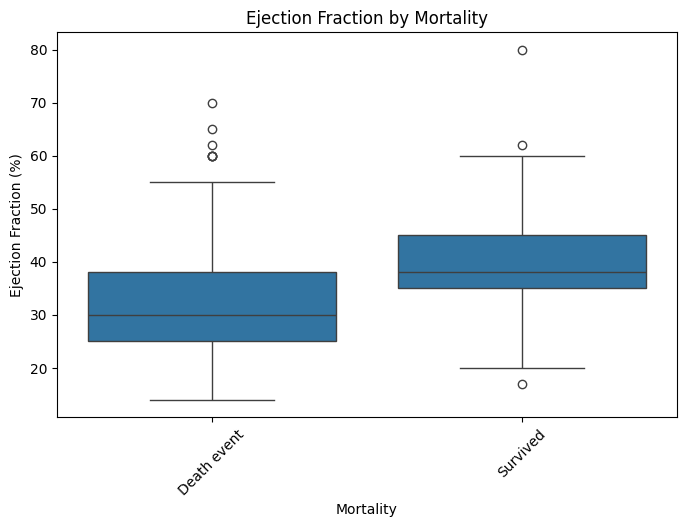

In [ ]:
#Ejection Fraction based on mortality Box Plot to support above analysis
plt.figure(figsize=(8, 5))
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df)
plt.title('Ejection Fraction by Mortality')
plt.xlabel('Mortality')
plt.ylabel('Ejection Fraction (%)')
plt.xticks(rotation=45)
plt.show()
#

Above box plot compares ejection fraction between two outcome groups (survived and death), where distributions help determine if the two groups had different ejection fraction values. The death event group had lower values which matches the results of the t-test.

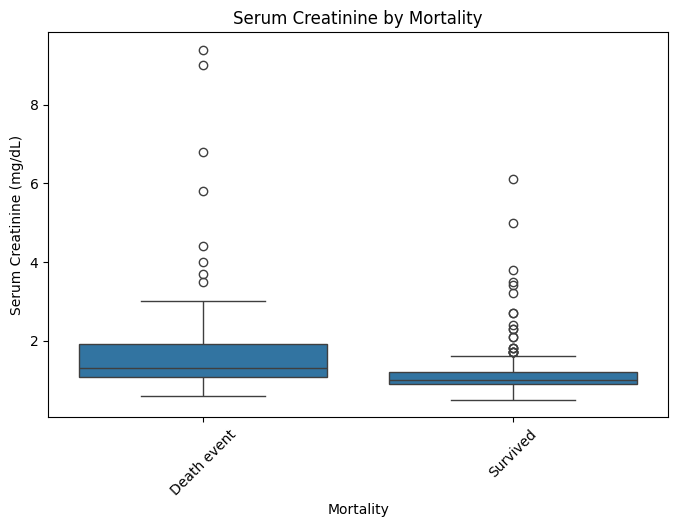

In [ ]:
#Serum Creatinine based on mortality Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)
plt.title('Serum Creatinine by Mortality')
plt.xlabel('Mortality')
plt.ylabel('Serum Creatinine (mg/dL)')
plt.xticks(rotation=45)
plt.show()
#

This box plot compares serum creatinine levels between two outcome groups (survived and death), where distributions help determine if the two groups had different serum creatinine levels. The death event group had higher values compared to the survived group.

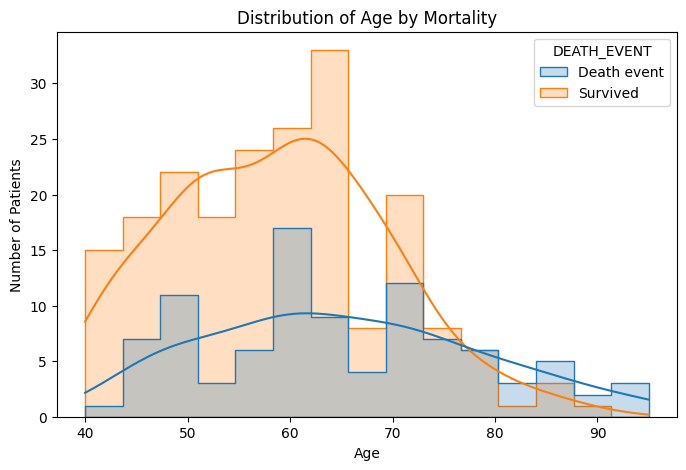

In [ ]:
#Age distribution histogram based on mortality
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='DEATH_EVENT', bins=15, kde=True, element='step')
plt.title('Distribution of Age by Mortality')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()
#

The above histogram shows the age distribution of patients and it's separated between those who survived and those with a death event. This helps us compare the two groups and patients within each group. Majority of patients who survived are in their early 60s or younger. The age distribution of patients who experienced the death event are more spread out, though also a little more concentrated in the middle (60s to 70s).

In [ ]:
#Mortality Rate based on age group
mortality_rate = (df.groupby('age_group', observed=True)['DEATH_EVENT'].value_counts(normalize=True).mul(100).reset_index(name='mortality_rate'))
mortality_rate = mortality_rate[mortality_rate['DEATH_EVENT'] == 'Death event']
print(mortality_rate)
#

  age_group  DEATH_EVENT  mortality_rate
1  Under 50  Death event       23.404255
3     50-59  Death event       24.390244
5     60-69  Death event       29.032258
7       70+  Death event       49.350649


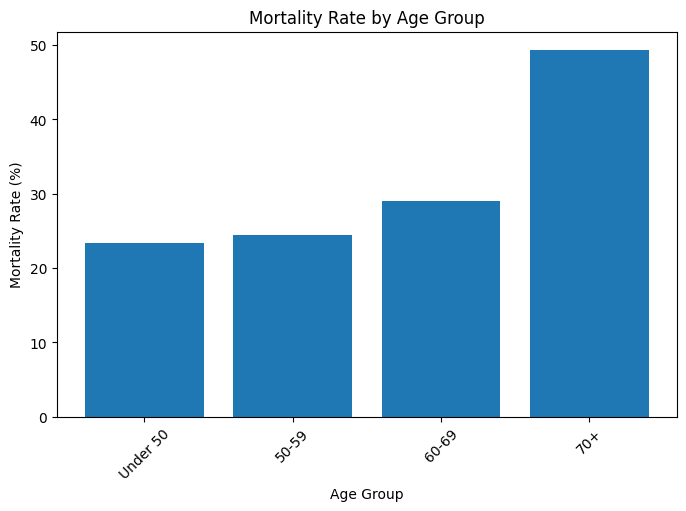

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(mortality_rate['age_group'], mortality_rate['mortality_rate'], data=mortality_rate)
plt.title('Mortality Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Mortality Rate (%)')
plt.xticks(rotation=45)
plt.show()
#

This bar plot compares the mortality rate among different age groups. Mortality rate is highest for age group 70+ at 49.35%. This shows that age does affect death event due to heart failure.

Notes for my PowerPoint presentation below:

The dataset I chose is the clinical records of patients diagnosed with heart failure.

I am interested in medical research or any research really, so this data set caught my eye.

It’s important to understand what could contribute to a higher chance of heart failure, whether it be your age or treatments.

Research Question- How do certain clinical features, such as age, ejection fraction and serum creatinine associated with death among patients experiencing heart failure?

Anemia is the deficiency of red blood cells (it carries oxygen to your body tissues)

Creatinine phosphokinase of cpk is an enzyme that helps muscle cells produce and use energy, found in your heart muscle and brain. The unit for it is micrograms per liter and is elevated due to medications, intense exercise, muscle disease, heart muscle injury

Ejection fraction is the percentage of blood leaving the heart with each contraction or heartbeat. Normal is around 50-70%

Platelets are small fragments (disc shaped)in the blood that forms clots wherever ur bleeding to stop it. Measured in kiloplatelets per milliliter

Serum creatinine is waste product produced from normal muscle breakdown filtered by the kidneys. If its levels are high, kidneys are not functioning well. Milligram per deciliter

Serum sodium is the concentration of sodium in ur blood. Solium regulates fluid balance in ur body and is important for nerve function and muscle activity. It’s measured in Milliequivalents per liter

Time is the Follow up period which is the period after diagnosis where they monitor you


So my first question is if there is significant difference in ejection fraction between the two outcomes groups. For this is I did Welch’s two sample t-test and if the p value is lower than 0.05, which it was (9.65 x 10^-6). There is significant difference. The average ejection fraction for survivors is around 40.27% and 33.47% for those with a death event, meaning there is a 6.80% difference. The box plot shows the death event group has lower values which matches the result of the t test.

From scipy import stats is allows me to perform the t test (also good for other statistical tests). It stands for scientific python and it’s a library used for scientific and mathematical reasons

This is the box plot for serum creatinine levels by mortality, where distributions help determine if the two groups have different levels. Death event group had higher values so kidneys aren’t well

Serum creatinine box plot also shows difference in levels among patients in same group.

This histogram shows the age distribution of patients and is separated between those who survived heart failure and those who didn’t. It helps us compare the two outcome groups as well as the patients within each group. Majority of survivors are in their 60s or younger. However the age distribution for the death event group are more spread out, but u can still see that it’s more concentrated in the middle 60s to 70s

Hue separates the ages into survived and death event from death event column. Bins divide age range in 15 intervals. Kde=adds the smooth curve (line) to show shape of distributions. Element=‘step’ makes the histograms look more like outlines (blurred) to make easier to compare.

The last visualization (a bar plot) also involves age groups but this time it’s about the mortality rate. In the beginning I created age groups so I used that.

Observed true only includes age groups with patients

I used value count normalize true because I changed the binary values of death event column into words. This counts amount of times a value appears in age group and proportion of the total patients in age group (ex. 10 patients in age group, 6 survived  so it’s 0.60)

Mul(100) converts the decimal into a percentage

Reset index creates a table with two columns (mortality rate and age group)

This graph compares mortality rate among different different age groups. Mortality rate is highest for 70+ at around 49.35%. This shows that age to affect death event due to heart failure.


Conclusion:

Results from analyzing the data set were as I expected which was that certain clinical characteristics were associated with mortality among patients with heart failure. I didn’t even know a couple of these terms until now. Age distribution showed differences between those who survived heart failure and those who experienced a death event. Mortality rate increases as age group increase. Patients who survived heart failure also have a higher average ejection rate as shown through the t test. Overall, my findings are consistent with what I expected.